## Pearson and Spearman Correlation Analysis

### Objective

This EDA step evaluates how the four structural features—`lcd`, `pld`, `void_fraction`, and `surface_area_m2g`—are associated with CO₂ uptake at five pressures.

For each feature–target pair, the analysis will determine:

* The direction of the relationship: positive or negative.
* The strength of the relationship.
* Whether the relationship changes in strength or direction with pressure.
* Whether the relationship appears linear or monotonic but nonlinear.

| Method               | What It Measures                                                                                                 |
| -------------------- | ---------------------------------------------------------------------------------------------------------------- |
| Pearson correlation  | Strength and direction of a linear relationship                                                                  |
| Spearman correlation | Strength and direction of a monotonic relationship based on ranked values; it can detect some nonlinear patterns |

Correlation coefficients range from -1 to +1:

* Values close to +1 indicate a strong positive relationship.
* Values close to -1 indicate a strong negative relationship.
* Values close to 0 indicate a weak or undetected relationship.

For example, the analysis will test whether the association between `surface_area_m2g` and CO₂ uptake becomes stronger, weaker, or changes direction as pressure increases.



**The main scientific hypothesis is:**

Different structural features may be associated with CO₂ uptake at different pressures.

This hypothesis will be tested rather than assumed.

### Expected Outcomes

The analysis will produce:

* A Pearson correlation table containing four features × five pressure targets.
* A Spearman correlation table with the same structure.
* Identification of the strongest positive and negative correlations at each pressure.
* Comparison of correlation strength and direction across the five pressures.
* Identification of relationships where Spearman is notably stronger than Pearson, suggesting a potentially monotonic but nonlinear pattern that requires visualization.
* A shortlist of feature–target relationships for further investigation using scatterplots or hexbin plots.

### Interpretation Limitations

Correlation analysis does not prove:

* That a structural feature causes CO₂ uptake to increase or decrease.
* That a feature will be important in a multivariable machine-learning model.
* That a stronger Spearman correlation confirms a nonlinear relationship; it only identifies a pattern that should be investigated visually.
* That a near-zero correlation means the feature is useless, because the relationship may be non-monotonic or depend on interactions with other features.
              ======================================================

In [5]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load Data
data = pd.read_csv('/home/susan/MOF_project/data/processed/data_clean_v2')
# Copy dataframe
df= data.copy()
print(df.columns)
print("="*30)
print()



Index(['filename', 'lcd', 'pld', 'void_fraction', 'surface_area_m2g', 'mofid',
       'CO2_uptake_0.01bar_molkg', 'CO2_uptake_0.05bar_molkg',
       'CO2_uptake_0.1bar_molkg', 'CO2_uptake_0.5bar_molkg',
       'CO2_uptake_2.5bar_molkg'],
      dtype='object')



## Step 1 — Prepare and Validate the Data



In [6]:
#1A. Define the features and targets
# Store the four structural features used in the relationship analysis.
feature_columns = ["lcd", "pld", "void_fraction", "surface_area_m2g"]

# Store the five CO2-uptake targets in increasing pressure order.
target_columns = ["CO2_uptake_0.01bar_molkg", "CO2_uptake_0.05bar_molkg", "CO2_uptake_0.1bar_molkg", "CO2_uptake_0.5bar_molkg", "CO2_uptake_2.5bar_molkg"]

# Combine the feature and target column names into one list.
correlation_columns = feature_columns + target_columns

# Select only the columns required for correlation analysis.
correlation_data = df[correlation_columns].copy()

# Display the first five records to confirm that the correct columns were selected.
display(correlation_data.head())


,lcd,pld,void_fraction,surface_area_m2g,CO2_uptake_0.01bar_molkg,CO2_uptake_0.05bar_molkg,CO2_uptake_0.1bar_molkg,CO2_uptake_0.5bar_molkg,CO2_uptake_2.5bar_molkg
0,11.75,10.75,0.795539,3676.3,0.022406,0.073552,0.225851,0.885221,4.33307
1,4.75,3.25,0.388986,580.7,0.173407,0.925813,1.806490,4.779010,7.34618
2,4.75,3.75,0.307505,377.6,0.651164,2.129830,2.817220,3.909470,4.93236
3,9.25,8.25,0.731919,3399.2,0.031321,0.143123,0.332034,1.756380,6.91190
4,3.75,2.75,0.323803,85.2,0.144024,0.698367,1.402230,2.694200,4.15694


In [12]:
# 1B. Check the dataset dimensions
# Display the number of rows and columns in the correlation dataset.
print("Correlation data shape:", correlation_data.shape)
# Display the number of rows and columns in the correlation dataset.
print("Correlation data shape:", correlation_data.shape)

# Display the total number of records.
print("Number of MOFs:", correlation_data.shape[0])

# Display the total number of selected variables.
print("Number of variables:", correlation_data.shape[1])


Correlation data shape: (31234, 9)
Correlation data shape: (31234, 9)
Number of MOFs: 31234
Number of variables: 9


In [15]:
# Display the data type of each selected feature and target.
display(correlation_data.dtypes.to_frame(name="data_type"))
# Find any selected columns that are not numeric.
non_numeric_columns = correlation_data.select_dtypes(
    exclude="number"
).columns.tolist()
print(non_numeric_columns)

,data_type
lcd,float64
pld,float64
void_fraction,float64
surface_area_m2g,float64
CO2_uptake_0.01bar_molkg,float64
CO2_uptake_0.05bar_molkg,float64
CO2_uptake_0.1bar_molkg,float64
CO2_uptake_0.5bar_molkg,float64
CO2_uptake_2.5bar_molkg,float64


[]


=================================================
We check for infinite values because a column can be float64 and still contain:

inf (positive infinity)
-inf (negative infinity)

These are different from missing values (NaN). They may result from calculations such as division by zero. Pearson and Spearman correlations require finite numerical values; infinity can make the correlation result invalid or return NaN.

## Decision Before Calculating Correlation

Proceed only if:

* The shape is (31234, 9).
* All nine columns are numeric.
* Missing-value counts are zero.
* Infinite-value counts are zero.

===========================================================

In [16]:
# Check every value and count infinite values in each column.
infinite_count = pd.Series(
    np.isinf(correlation_data.to_numpy()).sum(axis=0),
    index=correlation_data.columns,
    name="infinite_count",
)

# Display the number of infinite values in each column.
display(infinite_count.to_frame())

,infinite_count
lcd,0
pld,0
void_fraction,0
surface_area_m2g,0
CO2_uptake_0.01bar_molkg,0
CO2_uptake_0.05bar_molkg,0
CO2_uptake_0.1bar_molkg,0
CO2_uptake_0.5bar_molkg,0
CO2_uptake_2.5bar_molkg,0


In [17]:
# Calculate Pearson correlations among all four features and five targets.
pearson_matrix = correlation_data.corr(method="pearson")

# Extract only the correlations between the four features and five targets.
pearson_feature_target = pearson_matrix.loc[
    feature_columns,
    target_columns
]

# Display the feature–target correlation table rounded to three decimals.
display(pearson_feature_target.round(3))

,CO2_uptake_0.01bar_molkg,CO2_uptake_0.05bar_molkg,CO2_uptake_0.1bar_molkg,CO2_uptake_0.5bar_molkg,CO2_uptake_2.5bar_molkg
lcd,-0.391,-0.480,-0.509,-0.505,-0.196
pld,-0.381,-0.474,-0.506,-0.519,-0.234
void_fraction,-0.411,-0.446,-0.436,-0.283,0.210
surface_area_m2g,-0.468,-0.547,-0.559,-0.457,0.066


In [18]:
# Step 3 — Calculate Spearman Correlations
# Calculate Spearman correlations among all selected features and targets.
spearman_matrix = correlation_data.corr(method="spearman")

# Extract only the correlations between the four features and five CO₂ targets.
spearman_feature_target = spearman_matrix.loc[
    feature_columns,
    target_columns
]

# Display the Spearman correlation table rounded to three decimal places.
display(spearman_feature_target.round(3))

,CO2_uptake_0.01bar_molkg,CO2_uptake_0.05bar_molkg,CO2_uptake_0.1bar_molkg,CO2_uptake_0.5bar_molkg,CO2_uptake_2.5bar_molkg
lcd,-0.667,-0.665,-0.659,-0.566,-0.091
pld,-0.670,-0.667,-0.660,-0.572,-0.128
void_fraction,-0.640,-0.633,-0.622,-0.504,0.006
surface_area_m2g,-0.664,-0.658,-0.647,-0.517,0.052


## Scatterplot and Hexbin Analysis

### Objective

This EDA step visually examines how each structural feature—`lcd`, `pld`, `void_fraction`, and `surface_area_m2g`—relates to CO₂ uptake at each pressure.

### Advantages of the Plots

- Scatterplots show individual observations, outliers, and the overall relationship pattern.
- Hexbin plots group nearby observations into colored regions that represent data density.
- Hexbin plots are especially useful for this dataset because plotting 31,234 points can create excessive overlap in a regular scatterplot.

### Expected Outcome

The plots will help us:

- Confirm whether the correlation patterns are visible in the data.
- Identify potentially nonlinear feature–uptake relationships.
- Detect dense regions, clusters, gaps, and unusual observations.
- Determine whether relationships change across pressure levels.
- Select patterns that may require further analysis.

These two-variable plots do not directly prove feature interactions. Feature interactions will require additional plots or modeling methods involving multiple features.

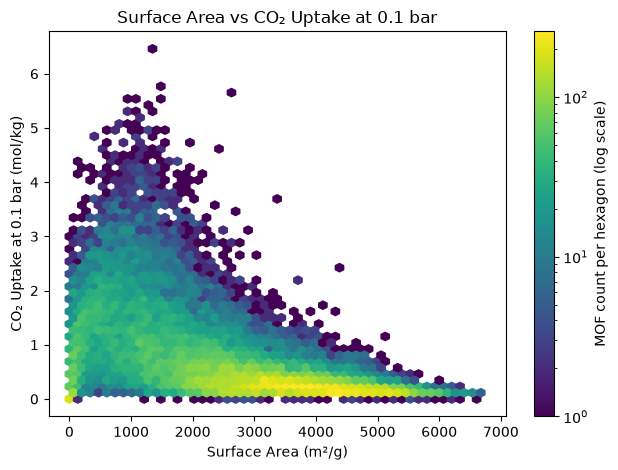

In [20]:
# Create a hexbin plot for surface area and CO2 uptake at 0.1 bar.
hexbin_plot = plt.hexbin(
    correlation_data["surface_area_m2g"],
    correlation_data["CO2_uptake_0.1bar_molkg"],
    gridsize=50,
    cmap="viridis",
    mincnt=1,
    bins="log",
)
# Add a color bar showing the number of MOFs in each hexagonal region.
colorbar = plt.colorbar(hexbin_plot)

# Label the color bar.
colorbar.set_label("MOF count per hexagon (log scale)")

# Label the horizontal axis.
plt.xlabel("Surface Area (m²/g)")

# Label the vertical axis.
plt.ylabel("CO₂ Uptake at 0.1 bar (mol/kg)")

# Add a title.
plt.title("Surface Area vs CO₂ Uptake at 0.1 bar")

# Adjust the layout to prevent labels from being cut off.
plt.tight_layout()

# Display the plot.
plt.show()

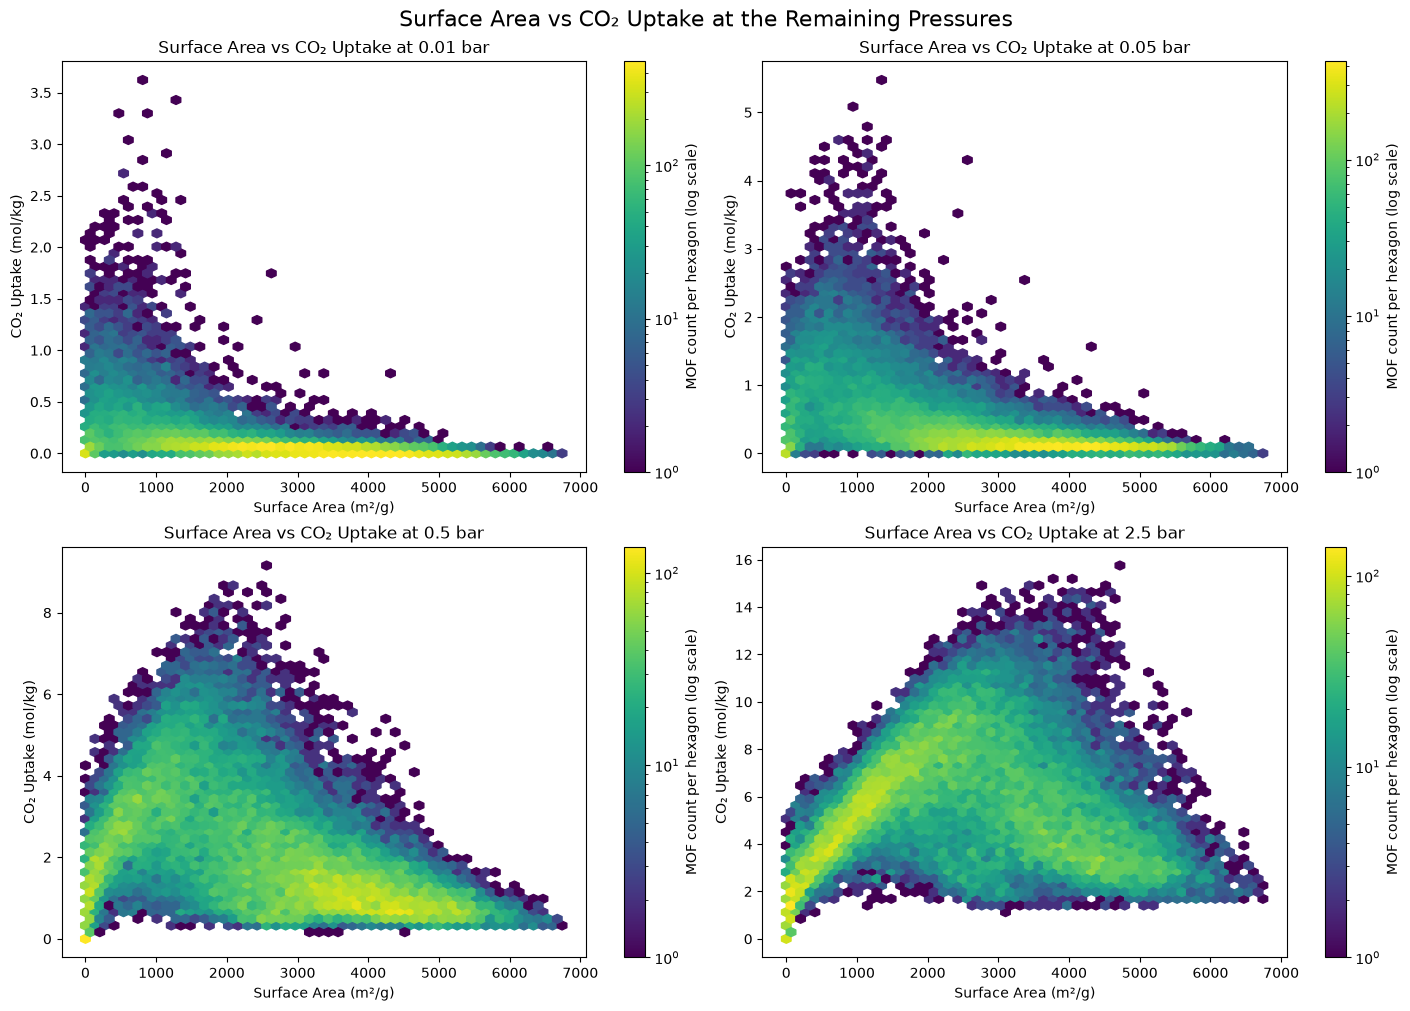

In [24]:
# Store the four pressure targets that have not been plotted yet.
remaining_targets = [
    "CO2_uptake_0.01bar_molkg",
    "CO2_uptake_0.05bar_molkg",
    "CO2_uptake_0.5bar_molkg",
    "CO2_uptake_2.5bar_molkg",
]

# Create short pressure labels for the subplot titles.
remaining_pressure_labels = [
    "0.01 bar",
    "0.05 bar",
    "0.5 bar",
    "2.5 bar",
]
# Create a figure containing four subplots arranged in two rows.
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
    constrained_layout=True,
)

# Convert the 2 × 2 axes structure into a simple list.
axes = axes.flatten()

# Match each target and pressure label with one subplot.
for ax, target, pressure in zip(
    axes,
    remaining_targets,
    remaining_pressure_labels,
):

    # Create a hexbin plot for surface area and the current uptake target.
    hexbin_plot = ax.hexbin(
        correlation_data["surface_area_m2g"],
        correlation_data[target],
        gridsize=50,
        cmap="viridis",
        mincnt=1,
        bins="log",
    )

    # Add a color bar showing the MOF density.
    colorbar = fig.colorbar(hexbin_plot, ax=ax)

    # Label the color bar.
    colorbar.set_label("MOF count per hexagon (log scale)")

    # Label the horizontal axis.
    ax.set_xlabel("Surface Area (m²/g)")

    # Label the vertical axis.
    ax.set_ylabel("CO₂ Uptake (mol/kg)")

    # Add the pressure to the plot title.
    ax.set_title(f"Surface Area vs CO₂ Uptake at {pressure}")

# Add one title for the complete figure.
fig.suptitle(
    "Surface Area vs CO₂ Uptake at the Remaining Pressures",
    fontsize=16,
)

# Display the complete figure.
plt.show()

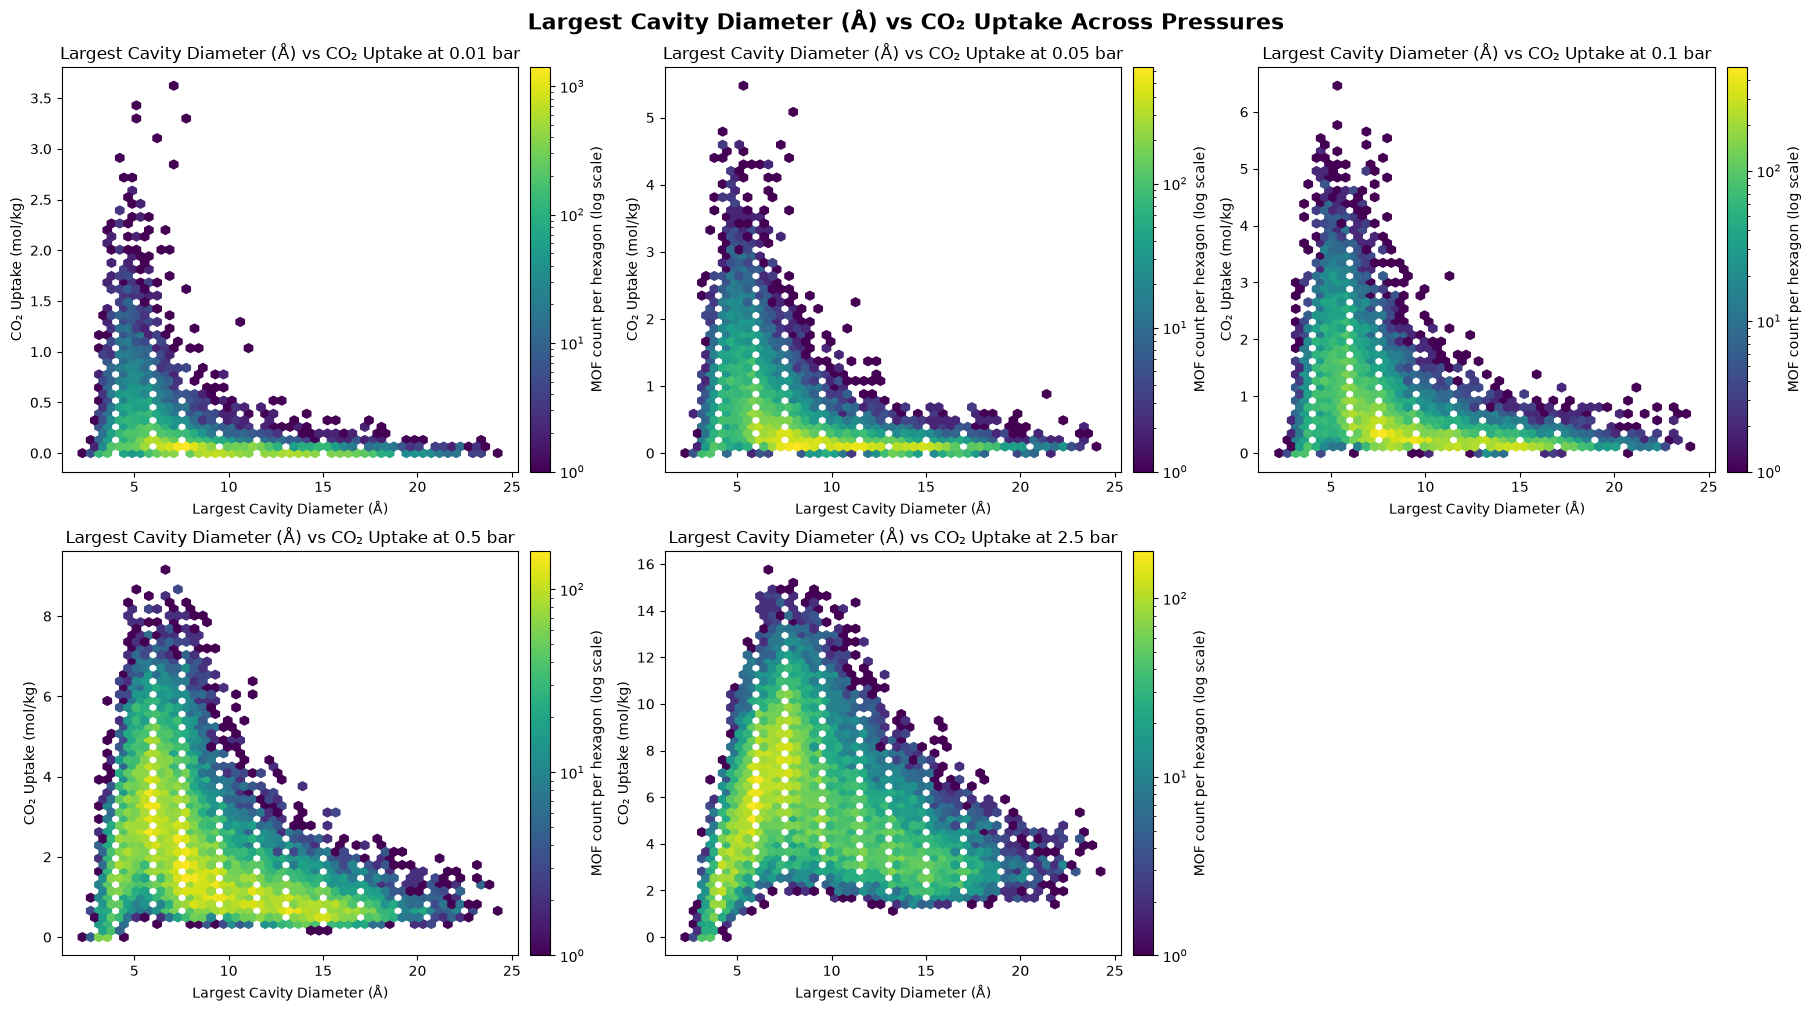

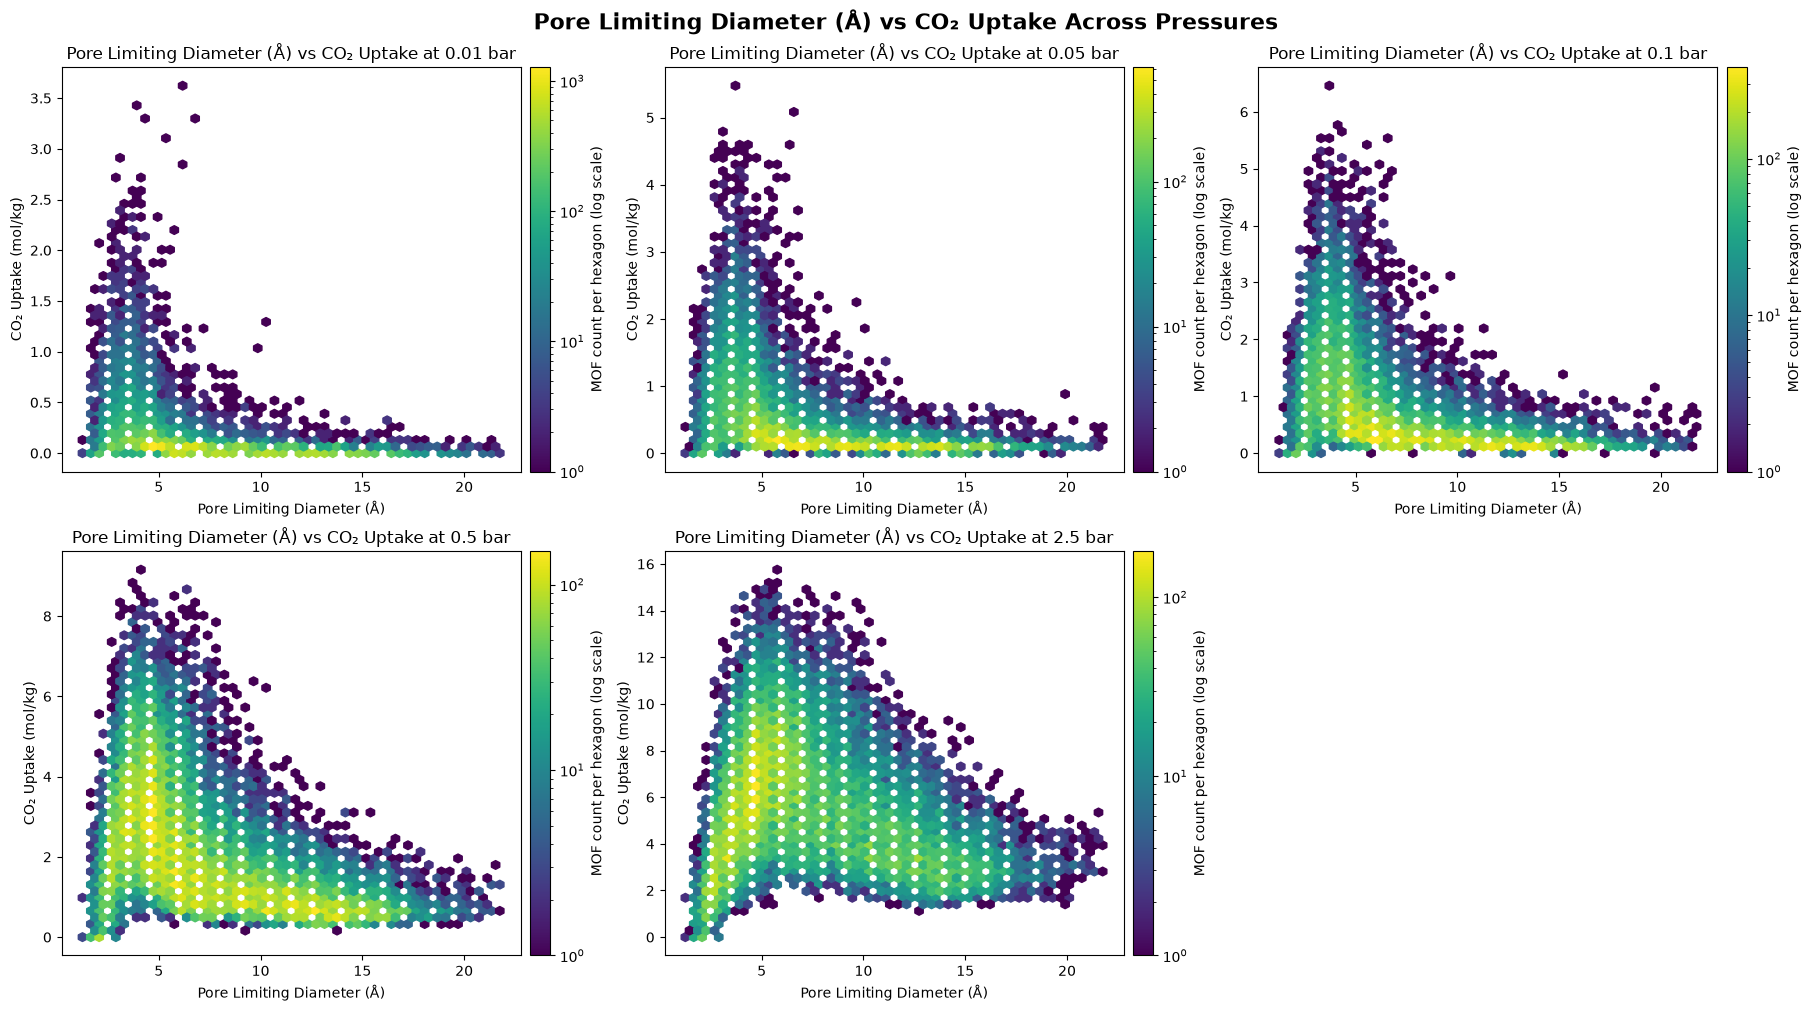

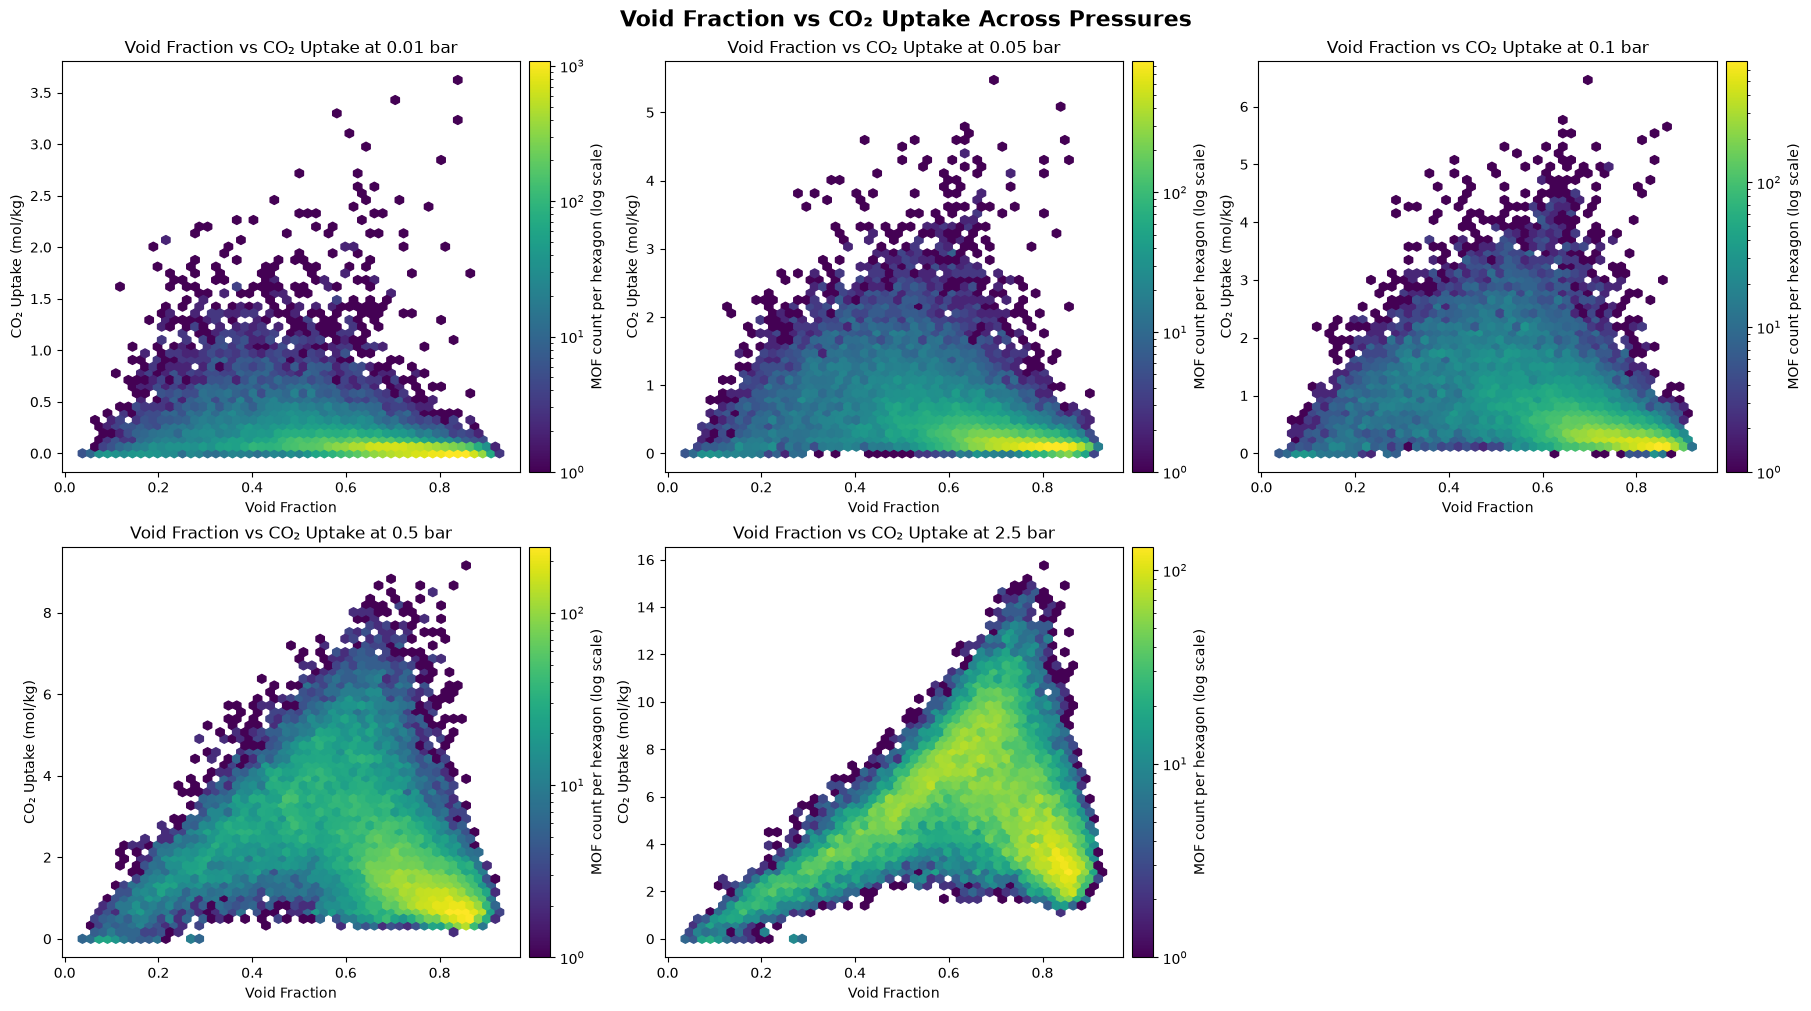

In [25]:

# Store the three remaining features and their readable labels.
remaining_features = {
    "lcd": "Largest Cavity Diameter (Å)",
    "pld": "Pore Limiting Diameter (Å)",
    "void_fraction": "Void Fraction",
}

# Store the five CO₂-uptake targets and their pressure labels.
pressure_targets = {
    "CO2_uptake_0.01bar_molkg": "0.01 bar",
    "CO2_uptake_0.05bar_molkg": "0.05 bar",
    "CO2_uptake_0.1bar_molkg": "0.1 bar",
    "CO2_uptake_0.5bar_molkg": "0.5 bar",
    "CO2_uptake_2.5bar_molkg": "2.5 bar",
}


# Define a reusable function for plotting one feature at five pressures.
def plot_feature_across_pressures(dataframe, feature, feature_label):
    """
    Create five hexbin plots for one structural feature
    against CO₂ uptake at five pressures.
    """

    # Create six spaces arranged as two rows and three columns.
    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(18, 10),
        constrained_layout=True,
    )

    # Convert the axes array into a simple one-dimensional list.
    axes = axes.flatten()

    # Match each pressure target with one subplot.
    for ax, (target, pressure) in zip(
        axes,
        pressure_targets.items(),
    ):

        # Create the hexbin density plot.
        hexbin_plot = ax.hexbin(
            dataframe[feature],
            dataframe[target],
            gridsize=50,
            cmap="viridis",
            mincnt=1,
            bins="log",
        )

        # Add a color bar showing the MOF density.
        colorbar = fig.colorbar(
            hexbin_plot,
            ax=ax,
            pad=0.02,
        )

        # Label the color bar.
        colorbar.set_label(
            "MOF count per hexagon (log scale)"
        )

        # Label the horizontal axis.
        ax.set_xlabel(feature_label)

        # Label the vertical axis.
        ax.set_ylabel("CO₂ Uptake (mol/kg)")

        # Add the pressure to the subplot title.
        ax.set_title(
            f"{feature_label} vs CO₂ Uptake at {pressure}"
        )

    # Hide the unused sixth subplot.
    axes[-1].axis("off")

    # Add a title for the complete figure.
    fig.suptitle(
        f"{feature_label} vs CO₂ Uptake Across Pressures",
        fontsize=16,
        fontweight="bold",
    )

    # Display the completed figure.
    plt.show()


# Create one separate figure for each remaining feature.
for feature, feature_label in remaining_features.items():
    plot_feature_across_pressures(
        dataframe=correlation_data,
        feature=feature,
        feature_label=feature_label,
    )

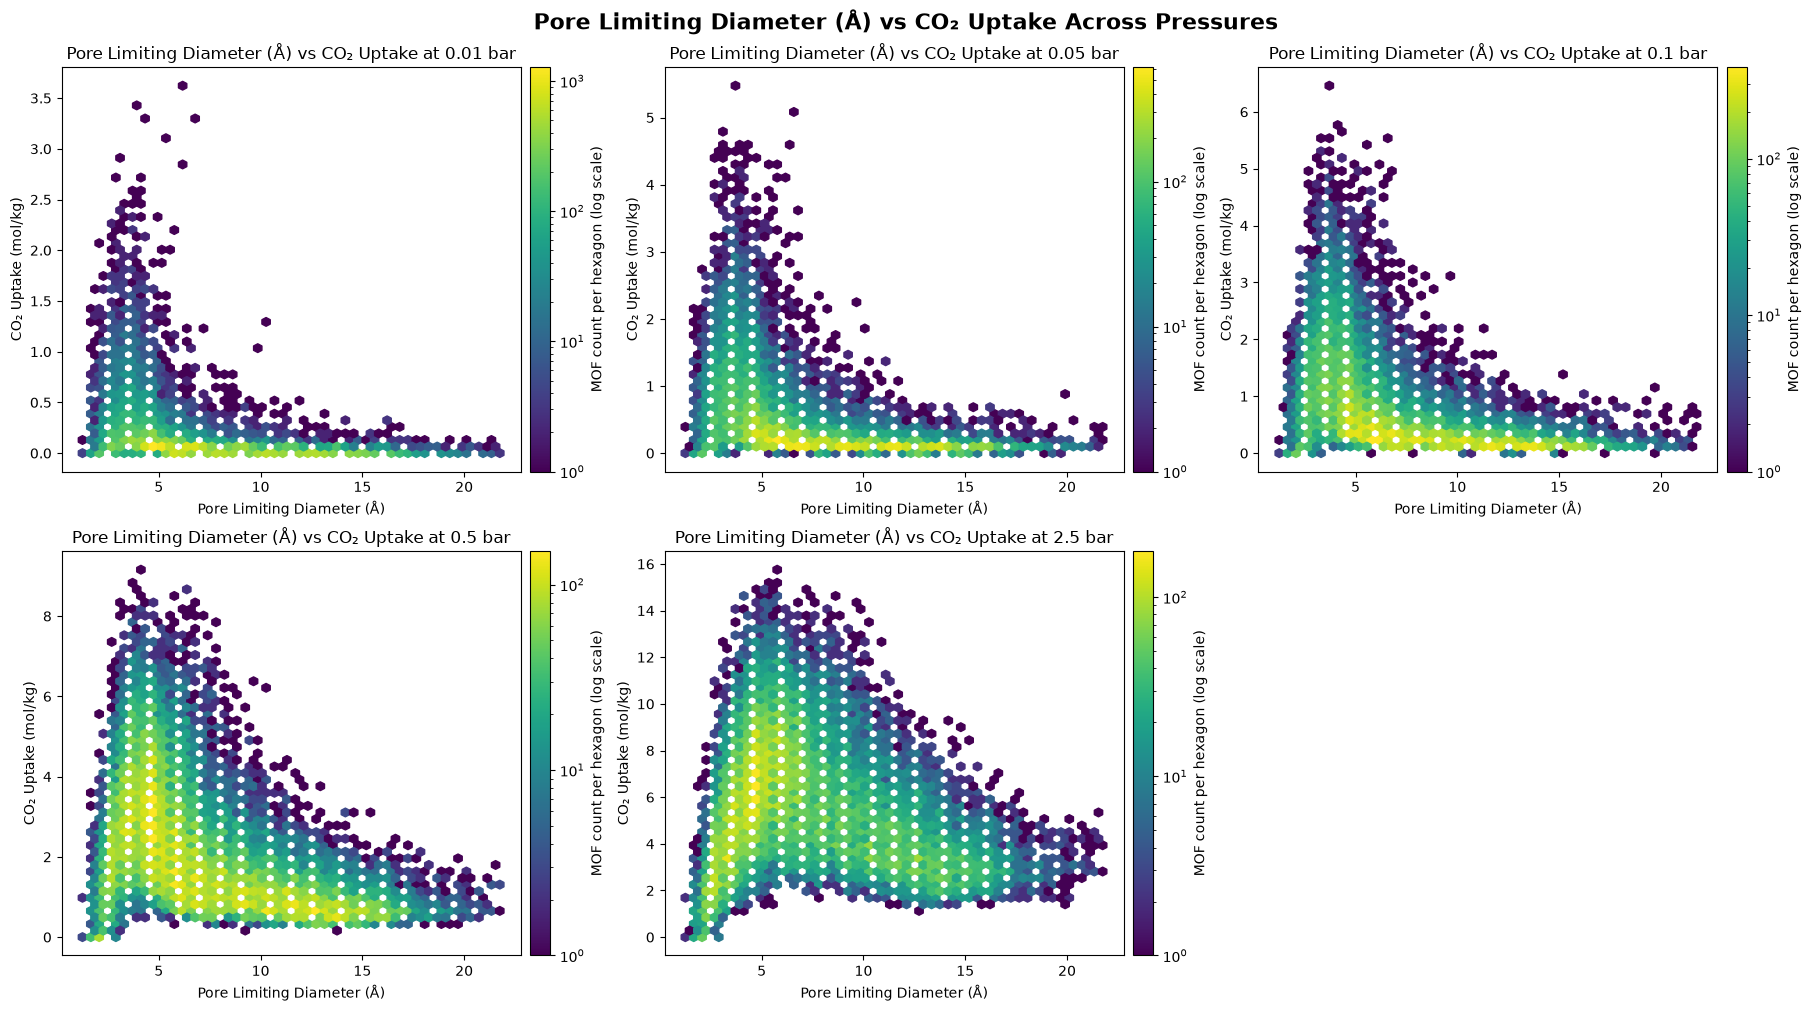

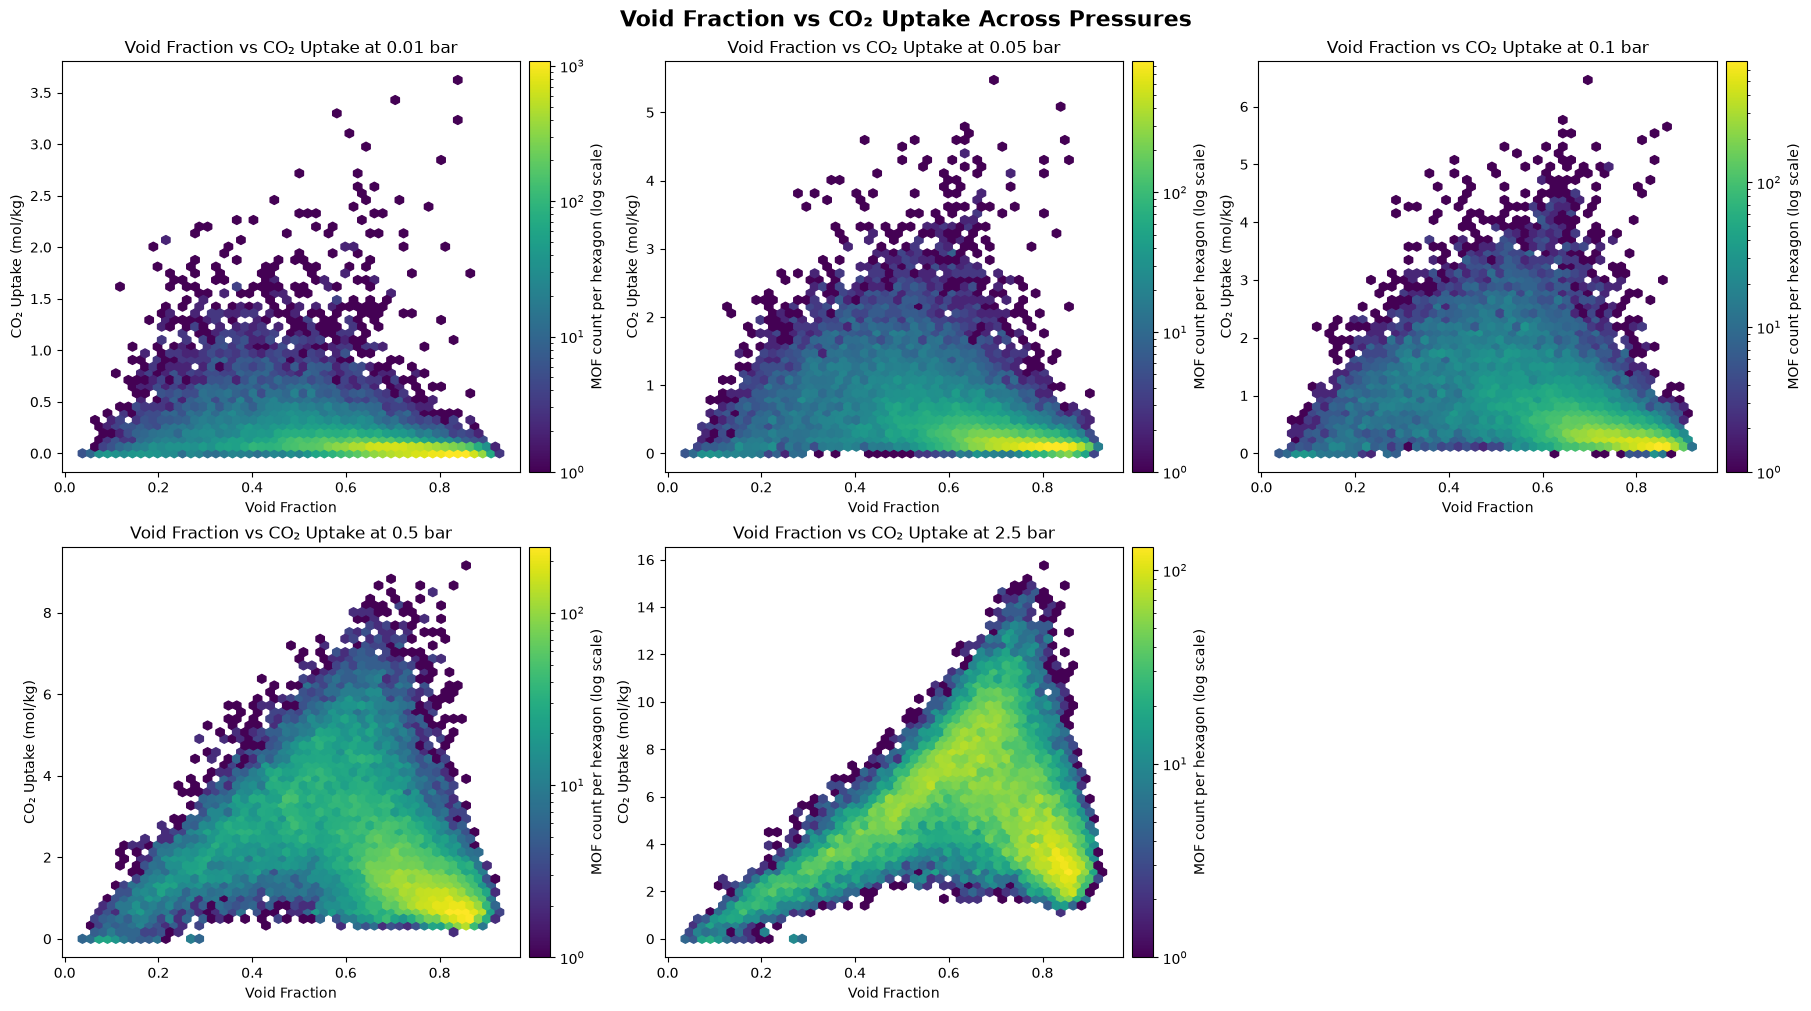

In [26]:
# Create the PLD hexbin plots across all five pressures.
plot_feature_across_pressures(
    dataframe=correlation_data,
    feature="pld",
    feature_label="Pore Limiting Diameter (Å)",
)

# Create the void-fraction hexbin plots across all five pressures.
plot_feature_across_pressures(
    dataframe=correlation_data,
    feature="void_fraction",
    feature_label="Void Fraction",
)